# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import LightGBMExperiment, sample_by_uid_group

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "different_sampling"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = 10
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [ ]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
path_data = os.path.join(FEATURE_ORIGINAL_DATA, 'features_40.csv')
path_data_augmented = os.path.join(FEATURE_AUGMENTED_DATA, 'features_40.csv')
path_data_balanced = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')

logtxt += f"\nOriginal Data Set (no augmentation)\n"

# Data

In [12]:
data = pd.read_csv(path_data)
data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)
print(f"Original Data: {len(data)}")

data_augmented = pd.read_csv(path_data_augmented)
data_augmented['uid'] = data_augmented['uid'].astype(str)
data_augmented['Class'] = data_augmented['Class'].astype(str)
print(f"Augmented Data: {len(data_augmented)}")

data_balanced = pd.read_csv(path_data_balanced)
data_balanced['uid'] = data_balanced['uid'].astype(str)
data_balanced['Class'] = data_balanced['Class'].astype(str)
print(f"Balanced Data: {len(data_balanced)}")

logtxt += f"Original Data: {len(data)}\n"
logtxt += f"Augmented Data: {len(data_augmented)}\n"
logtxt += f"Balanced Data: {len(data_balanced)}\n"


Original Data: 5894
Augmented Data: 81925
Balanced Data: 282753


Class
Ia         2620
II         1777
Ibc         340
TDE         339
CV          320
AGN         156
Other       105
SLSN         72
LBV          38
Nova         38
LRN          29
Unknown      27
M dwarf      12
LGRB          9
FBOT          7
FRB           5
Name: count, dtype: int64

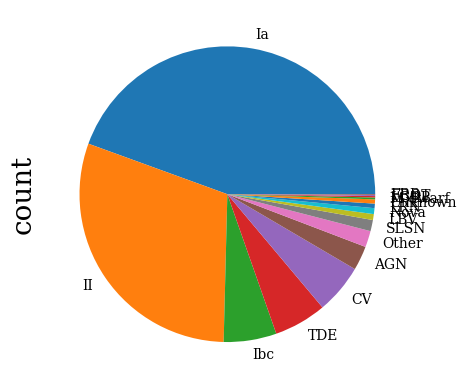

In [13]:
data['Class'].value_counts().plot.pie()
data['Class'].value_counts()

Class
Ia      37620
II      25630
TDE      4935
Ibc      4800
CV       4615
AGN      2225
SLSN     1020
LBV       540
Nova      540
Name: count, dtype: int64

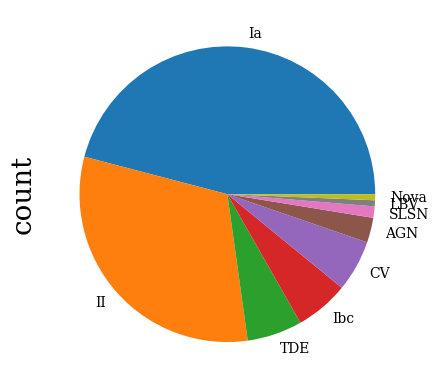

In [14]:
data_augmented['Class'].value_counts().plot.pie()
data_augmented['Class'].value_counts()

Class
II         31773
Ia         31148
AGN        29128
LBV        29083
CV         29026
Ibc        28563
Nova       28109
TDE        27446
SLSN       25675
M dwarf    22802
Name: count, dtype: int64

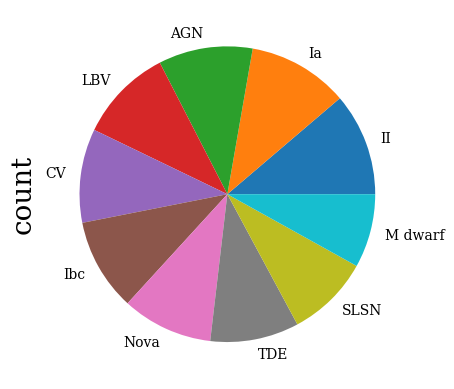

In [15]:
data_balanced['Class'].value_counts().plot.pie()
data_balanced['Class'].value_counts()

In [16]:
indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

indx_type_to_consider_augmented = np.where(
	np.array([(data_augmented['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

indx_type_to_consider_balanced = np.where(
	np.array([(data_balanced['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]
data_augmented = data_augmented.iloc[indx_type_to_consider_augmented[0]]
data_balanced = data_balanced.iloc[indx_type_to_consider_balanced[0]]

logtxt += f"Original: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += f"Augmented: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider_augmented[0])}\n"
logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider_balanced[0])}\n"
logtxt += "\n"

9 sources to consider: 5640


- Split features/target, handle missing values

In [17]:
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = data['Class']
X.fillna(-99, inplace=True)

X_augmented = data_augmented.drop(columns=['Sample_ID', 'Class', 'uid'])
y_augmented = data_augmented['Class']
X_augmented.fillna(-99, inplace=True)

X_balanced = data_balanced.drop(columns=['Sample_ID', 'Class', 'uid'])
y_balanced = data_balanced['Class']
X_balanced.fillna(-99, inplace=True)

In [18]:
y_balanced.unique()

array(['Ia', 'Ibc', 'II', 'CV', 'LBV', 'AGN', 'M dwarf', 'Nova', 'TDE'],
      dtype=object)

- Split into train/test using GroupShuffleSplit by uid

In [19]:
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_idx_augmented, test_idx_augmented = next(gss.split(X_augmented, y_augmented, groups=data_augmented['uid']))
X_train_augmented, X_test_augmented = X_augmented.iloc[train_idx_augmented], X_augmented.iloc[test_idx_augmented]
y_train_augmented, y_test_augmented = y_augmented.iloc[train_idx_augmented], y_augmented.iloc[test_idx_augmented]

train_idx_balanced, test_idx_balanced = next(gss.split(X_balanced, y_balanced, groups=data_balanced['uid']))
X_train_balanced, X_test_balanced = X_balanced.iloc[train_idx_balanced], X_balanced.iloc[test_idx_balanced]
y_train_balanced, y_test_balanced = y_balanced.iloc[train_idx_balanced], y_balanced.iloc[test_idx_balanced]

- Label encode class for ML

In [20]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)
print("Original: Class mapping:", label_encoder.inverse_transform(np.arange(len(label_encoder.classes_))))

y_train_augmented = label_encoder.transform(y_train_augmented)
y_test_augmented = label_encoder.transform(y_test_augmented)
print("Augmented: Class mapping:", label_encoder.inverse_transform(np.arange(len(label_encoder.classes_))))

y_train_balanced = label_encoder.transform(y_train_balanced)
y_test_balanced = label_encoder.transform(y_test_balanced)
print("Balanced: Class mapping:", label_encoder.inverse_transform(np.arange(len(label_encoder.classes_))))

Original: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'TDE']
Augmented: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'TDE']
Balanced: Class mapping: ['AGN' 'CV' 'II' 'Ia' 'Ibc' 'LBV' 'M dwarf' 'Nova' 'TDE']


# Tests

1. Original Data (no augmentation)
2. Augmented Data
3. Undersampling of the majority class
4. Oversampling of the minority class


In [44]:
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]

params = model_param_config['params_lightgbm']
params['num_class'] = len(label_encoder.classes_)
params

{'objective': 'multiclass',
 'num_class': 9,
 'force_col_wise': True,
 'early_stopping_rounds': 30,
 'device_type': 'cpu',
 'n_jobs': -1}

In [25]:
metrics_list = []
cm_dict = {}
eval_metrics_list = ["f1_macro", "f1_weighted", "precision_macro", "recall_macro", "accuracy"]

## Imbalanced Data
- Original
- Augmented (x same factor)

### 1. Original Data

[LightGBM] [Info] Total Bins 456450
[LightGBM] [Info] Number of data points in the train set: 4512, number of used features: 1790
[LightGBM] [Info] Start training from score -3.602311
[LightGBM] [Info] Start training from score -2.849975
[LightGBM] [Info] Start training from score -1.150466
[LightGBM] [Info] Start training from score -0.768620
[LightGBM] [Info] Start training from score -2.801368
[LightGBM] [Info] Start training from score -5.013298
[LightGBM] [Info] Start training from score -6.016601
[LightGBM] [Info] Start training from score -5.047200
[LightGBM] [Info] Start training from score -2.838547
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 30 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

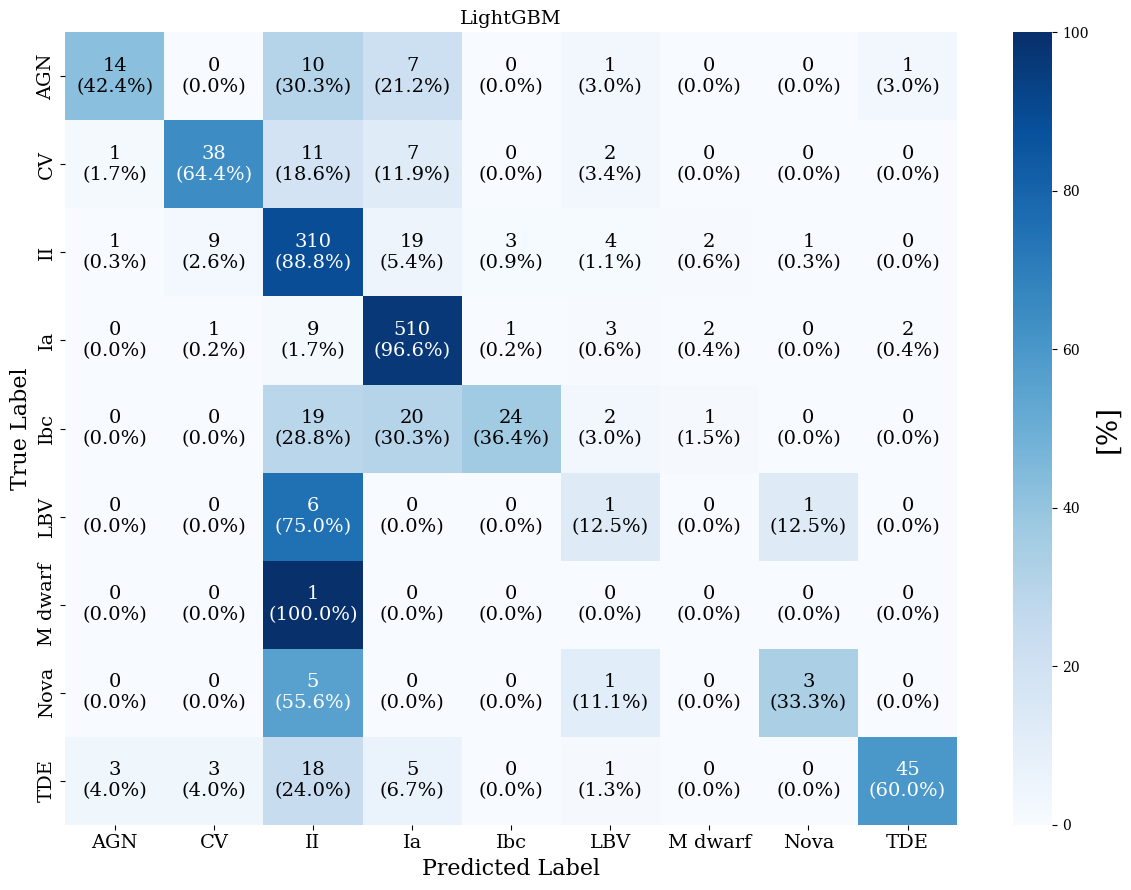

In [26]:
lgbm_exp = LightGBMExperiment(
    X_train, X_test, y_train, y_test,
    data, label_encoder, params,
    eval_metrics_list, path_save, do_cv=False
)

model, metrics = lgbm_exp.run()

lgbm_exp.plot_confusion_matrix()
cm, labels = lgbm_exp.get_confusion_matrix()
cm_dict['original'] = cm

metrics['test_name'] = 'original'
metrics_list.append(metrics)

### 2. Augmented Data

[LightGBM] [Info] Total Bins 456450
[LightGBM] [Info] Number of data points in the train set: 64735, number of used features: 1790
[LightGBM] [Info] Start training from score -3.636737
[LightGBM] [Info] Start training from score -2.864676
[LightGBM] [Info] Start training from score -1.155257
[LightGBM] [Info] Start training from score -0.753724
[LightGBM] [Info] Start training from score -2.856578
[LightGBM] [Info] Start training from score -5.151131
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Info] Start training from score -4.968810
[LightGBM] [Info] Start training from score -2.799121
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[46]	train's multi_logloss: 0.103486	test's multi_logloss: 0.51742


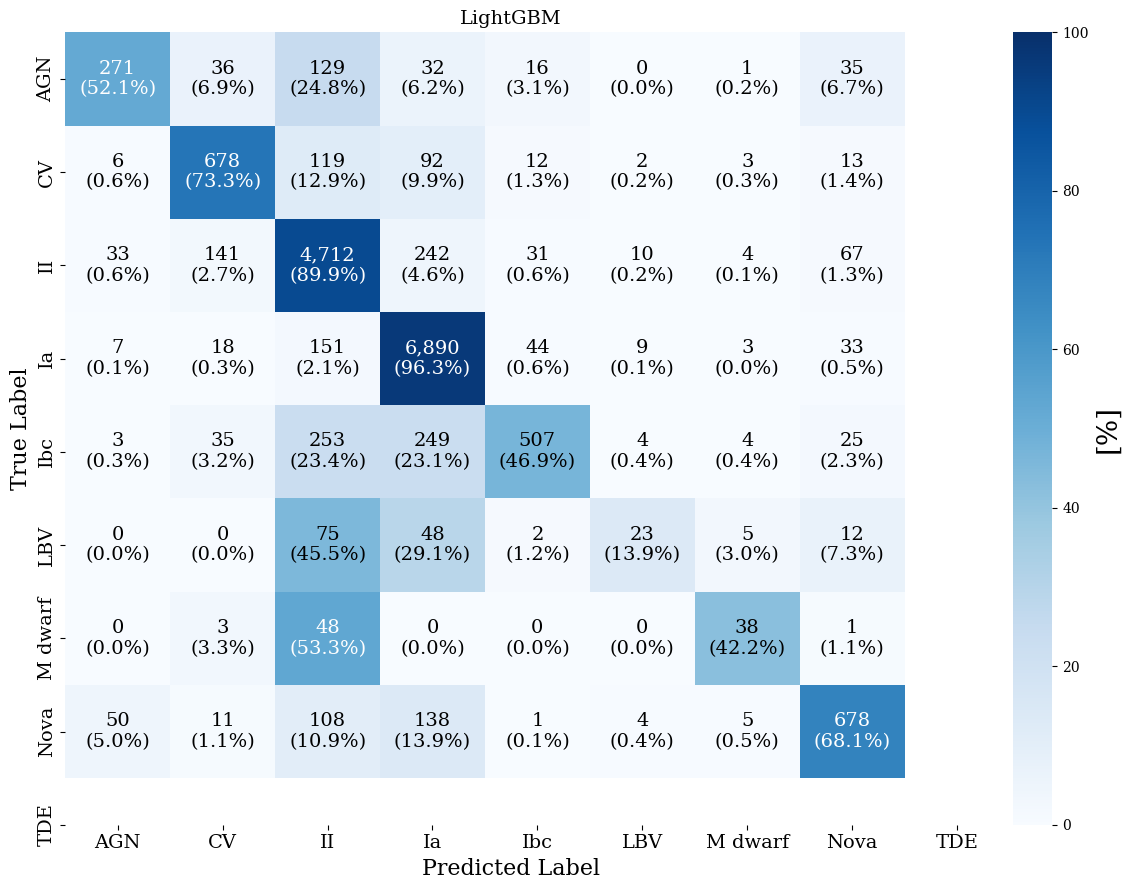

In [27]:
lgbm_exp_augmented = LightGBMExperiment(
    X_train_augmented, X_test_augmented, y_train_augmented, y_test_augmented,
    data_augmented, label_encoder, params,
    eval_metrics_list, path_save, do_cv=False
)

model_augmented, metrics_augmented = lgbm_exp_augmented.run()

lgbm_exp_augmented.plot_confusion_matrix()
cm_augmented, labels_augmented = lgbm_exp_augmented.get_confusion_matrix()
cm_dict['augmented'] = cm_augmented

metrics_augmented['test_name'] = 'augmented'
metrics_list.append(metrics_augmented)

### 3. Undersampling

In [28]:
from collections import Counter
from sklearn.utils import resample

# Count label distribution
counter = Counter(y_train_augmented)
majority_class = counter.most_common(1)[0][0]
minority_class_size = min(counter.values())

print(f"Original class distribution (train): {counter}")
print(f"Undersampling majority class ({majority_class}) to match minority count ({minority_class_size})")

# Combine X and y for easy manipulation
train_df = X_train_augmented.copy()
train_df['Class'] = y_train_augmented
train_df['uid'] = data_augmented.iloc[train_idx_augmented]['uid'].values  # ensure uid is included

# Split into majority and minority class groups
majority_df = train_df[train_df['Class'] == majority_class]
minority_df = train_df[train_df['Class'] != majority_class]

# Undersample majority class
majority_undersampled_df = resample(
    majority_df,
    replace=False,
    n_samples=minority_class_size,
    random_state=random_state,
    stratify=majority_df['uid']  # optional: or use custom logic for group balance
)

# Combine back
balanced_train_df = pd.concat([minority_df, majority_undersampled_df])

# Shuffle
balanced_train_df = balanced_train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

# Re-separate
X_train_augmented_undersampled = balanced_train_df.drop(columns=['Class', 'uid'])
y_train_augmented_undersampled = balanced_train_df['Class'].values

Original class distribution (train): Counter({3: 30465, 2: 20390, 8: 3940, 4: 3720, 1: 3690, 0: 1705, 7: 450, 5: 375})
Undersampling majority class (3) to match minority count (375)


In [29]:
# lgbm_exp_undersampled = LightGBMExperiment(
#     X_train_augmented_undersampled, X_test_augmented, y_train_augmented_undersampled, y_test_augmented,
#     data_augmented, label_encoder, params,
#     eval_metrics_list, path_save, do_cv=False
# )

# model_undersampled, metrics_undersampled = lgbm_exp_undersampled.run()

# lgbm_exp_undersampled.plot_confusion_matrix()
# metrics_undersampled['test_name'] = 'undersampled'
# metrics_list.append(metrics_undersampled)

## Balanced Samples

### All Balanced Samples

In [30]:
np.unique(y_train_balanced, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 array([22539, 23030, 25496, 24982, 22790, 22989, 17422, 22852, 22073]))

[LightGBM] [Info] Total Bins 456450
[LightGBM] [Info] Number of data points in the train set: 204173, number of used features: 1790
[LightGBM] [Info] Start training from score -2.203721
[LightGBM] [Info] Start training from score -2.182170
[LightGBM] [Info] Start training from score -2.080446
[LightGBM] [Info] Start training from score -2.100812
[LightGBM] [Info] Start training from score -2.192646
[LightGBM] [Info] Start training from score -2.183952
[LightGBM] [Info] Start training from score -2.461234
[LightGBM] [Info] Start training from score -2.189929
[LightGBM] [Info] Start training from score -2.224613
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[25]	train's multi_logloss: 0.285783	test's multi_logloss: 0.869522


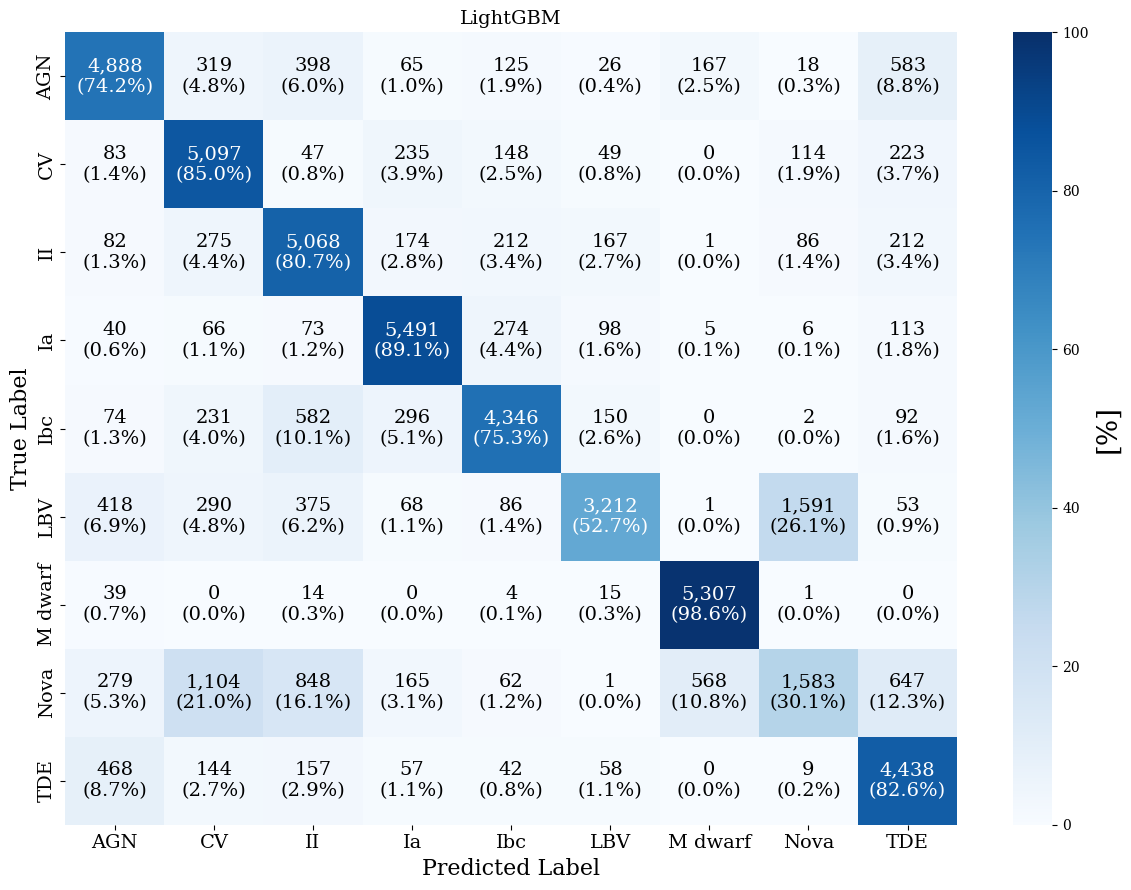

In [31]:
lgbm_exp_balanced = LightGBMExperiment(
    X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced,
    data_balanced, label_encoder, params,
    eval_metrics_list, path_save, do_cv=False
)

model_balanced, metrics_balanced = lgbm_exp_balanced.run()

lgbm_exp_balanced.plot_confusion_matrix()
cm_balanced, labels_balanced = lgbm_exp_balanced.get_confusion_matrix()
cm_dict['balanced'] = cm_balanced

metrics_balanced['test_name'] = 'balanced'
metrics_list.append(metrics_balanced)

### Varying Number of Samples

- Sampling Function and Test

In [32]:
def sample_by_class(X_balanced, y_balanced, data_balanced, sample_number_per_class):
	sampled_idx = []
	for c in y_balanced.unique():
		class_idx = y_balanced[y_balanced == c].index
		chosen = np.random.choice(class_idx, sample_number_per_class, replace=True)
		sampled_idx.extend(chosen)
		print(f"Class {c}: {len(chosen)} samples")
	sampled_idx = np.array(sampled_idx)

	X_balanced_choiced = X_balanced.loc[sampled_idx]
	y_balanced_choiced = y_balanced.loc[sampled_idx]
	uids_balanced_choiced = data_balanced['uid'][sampled_idx]

	gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
	train_idx_balanced_choiced, test_idx_balanced_choiced = next(gss.split(X_balanced_choiced, y_balanced_choiced, groups=uids_balanced_choiced))
	X_train_balanced_choiced, X_test_balanced_choiced = X_balanced_choiced.iloc[train_idx_balanced_choiced], X_balanced_choiced.iloc[test_idx_balanced_choiced]
	y_train_balanced_choiced, y_test_balanced_choiced = y_balanced_choiced.iloc[train_idx_balanced_choiced], y_balanced_choiced.iloc[test_idx_balanced_choiced]
	return X_train_balanced_choiced, X_test_balanced_choiced, y_train_balanced_choiced, y_test_balanced_choiced

sample_number = 5000
X_train_balanced_choiced, X_test_balanced_choiced, y_train_balanced_choiced, y_test_balanced_choiced = sample_by_class(X_balanced, y_balanced, data_balanced, sample_number)

print(f"X_train_balanced_choiced: {X_train_balanced_choiced.shape}")
print(f"X_test_balanced_choiced: {X_test_balanced_choiced.shape}")
print(f"y_train_balanced_choiced: {y_train_balanced_choiced.shape}")
print(f"y_test_balanced_choiced: {y_test_balanced_choiced.shape}")


Class Ia: 5000 samples
Class Ibc: 5000 samples
Class II: 5000 samples
Class CV: 5000 samples
Class LBV: 5000 samples
Class AGN: 5000 samples
Class M dwarf: 5000 samples
Class Nova: 5000 samples
Class TDE: 5000 samples
X_train_balanced_choiced: (35394, 1790)
X_test_balanced_choiced: (9606, 1790)
y_train_balanced_choiced: (35394,)
y_test_balanced_choiced: (9606,)


- Sampling method considering both uid and class

In [33]:
def sample_by_class_uidwise(
    X_balanced, y_balanced, data_balanced, sample_number_per_class, random_state=42
):
    np.random.seed(random_state)
    sampled_idx = []
    for c in y_balanced.unique():
        # 해당 클래스에서 uid 추출
        class_mask = (y_balanced == c)
        class_uids = data_balanced.loc[class_mask, 'uid'].unique()
        np.random.shuffle(class_uids)
        
        n_uids = len(class_uids)
        chosen_uids = class_uids[:min(n_uids, sample_number_per_class)]  # 가능한 uid를 먼저 선택
        
        # uid별로 한 개씩 샘플 선택 (랜덤)
        class_idx = y_balanced[class_mask].index
        class_tbl = data_balanced.loc[class_mask]
        chosen_idx = []
        for uid in chosen_uids:
            idxs = class_tbl[class_tbl['uid'] == uid].index
            chosen_idx.append(np.random.choice(idxs, 1)[0])
        
        # 부족분이 있으면, 남은 샘플에서 비복원 추출 (중복 없이)
        n_needed = sample_number_per_class - len(chosen_idx)
        remaining_idx = class_idx.difference(chosen_idx)
        # "남은 샘플 수" < "필요 샘플 수"면, 전체 남은 샘플을 모두 사용
        if n_needed > 0:
            if len(remaining_idx) <= n_needed:
                chosen_idx.extend(list(remaining_idx))
            else:
                chosen_idx.extend(np.random.choice(remaining_idx, n_needed, replace=False))
        
        sampled_idx.extend(chosen_idx)
        print(f"Class {c}: {len(chosen_idx)} samples, {len(set(data_balanced.loc[chosen_idx, 'uid']))} unique uids among {n_uids} uids")
    sampled_idx = np.array(sampled_idx)
    
    # 이후 과정 동일
    X_balanced_choiced = X_balanced.loc[sampled_idx]
    y_balanced_choiced = y_balanced.loc[sampled_idx]
    uids_balanced_choiced = data_balanced['uid'][sampled_idx]
    
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    train_idx_balanced_choiced, test_idx_balanced_choiced = next(
        gss.split(X_balanced_choiced, y_balanced_choiced, groups=uids_balanced_choiced)
    )
    X_train_balanced_choiced = X_balanced_choiced.iloc[train_idx_balanced_choiced]
    X_test_balanced_choiced  = X_balanced_choiced.iloc[test_idx_balanced_choiced]
    y_train_balanced_choiced = y_balanced_choiced.iloc[train_idx_balanced_choiced]
    y_test_balanced_choiced  = y_balanced_choiced.iloc[test_idx_balanced_choiced]
    return X_train_balanced_choiced, X_test_balanced_choiced, y_train_balanced_choiced, y_test_balanced_choiced

sample_number = 5000
X_train_balanced_choiced, X_test_balanced_choiced, y_train_balanced_choiced, y_test_balanced_choiced = sample_by_class_uidwise(X_balanced, y_balanced, data_balanced, sample_number)

print(f"X_train_balanced_choiced: {X_train_balanced_choiced.shape}")
print(f"X_test_balanced_choiced: {X_test_balanced_choiced.shape}")
print(f"y_train_balanced_choiced: {y_train_balanced_choiced.shape}")
print(f"y_test_balanced_choiced: {y_test_balanced_choiced.shape}")


Class Ia: 5000 samples, 2707 unique uids among 2707 uids
Class Ibc: 5000 samples, 345 unique uids among 345 uids
Class II: 5000 samples, 1805 unique uids among 1805 uids
Class CV: 5000 samples, 321 unique uids among 321 uids
Class LBV: 5000 samples, 38 unique uids among 38 uids
Class AGN: 5000 samples, 158 unique uids among 158 uids
Class M dwarf: 5000 samples, 13 unique uids among 13 uids
Class Nova: 5000 samples, 38 unique uids among 38 uids
Class TDE: 5000 samples, 340 unique uids among 340 uids
X_train_balanced_choiced: (35638, 1790)
X_test_balanced_choiced: (9362, 1790)
y_train_balanced_choiced: (35638,)
y_test_balanced_choiced: (9362,)


Class Ia: 5000 samples, 2707 unique uids among 2707 uids
Class Ibc: 5000 samples, 345 unique uids among 345 uids
Class II: 5000 samples, 1805 unique uids among 1805 uids
Class CV: 5000 samples, 321 unique uids among 321 uids
Class LBV: 5000 samples, 38 unique uids among 38 uids
Class AGN: 5000 samples, 158 unique uids among 158 uids
Class M dwarf: 5000 samples, 13 unique uids among 13 uids
Class Nova: 5000 samples, 38 unique uids among 38 uids
Class TDE: 5000 samples, 340 unique uids among 340 uids
[LightGBM] [Info] Total Bins 456450
[LightGBM] [Info] Number of data points in the train set: 35638, number of used features: 1790
[LightGBM] [Info] Start training from score -2.228722
[LightGBM] [Info] Start training from score -2.195907
[LightGBM] [Info] Start training from score -2.185120
[LightGBM] [Info] Start training from score -2.186618
[LightGBM] [Info] Start training from score -2.190123
[LightGBM] [Info] Start training from score -2.206811
[LightGBM] [Info] Start training from sco

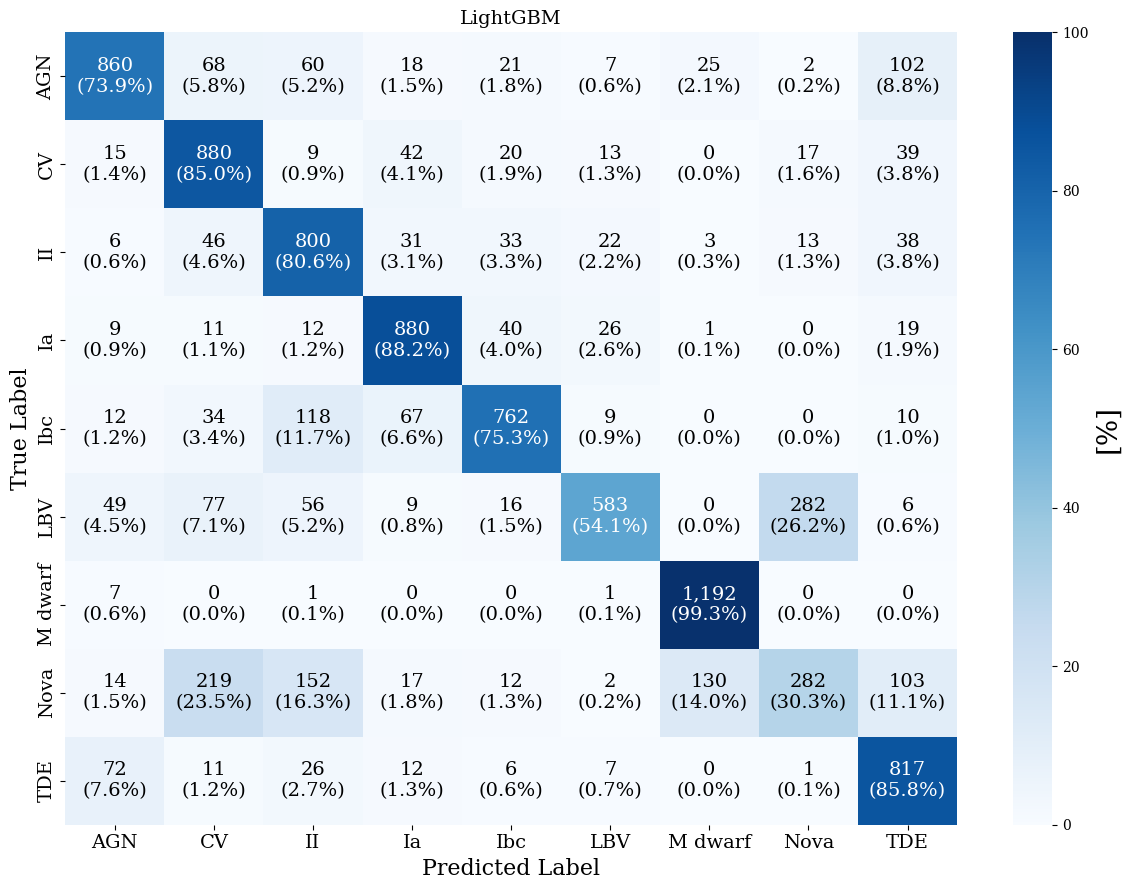

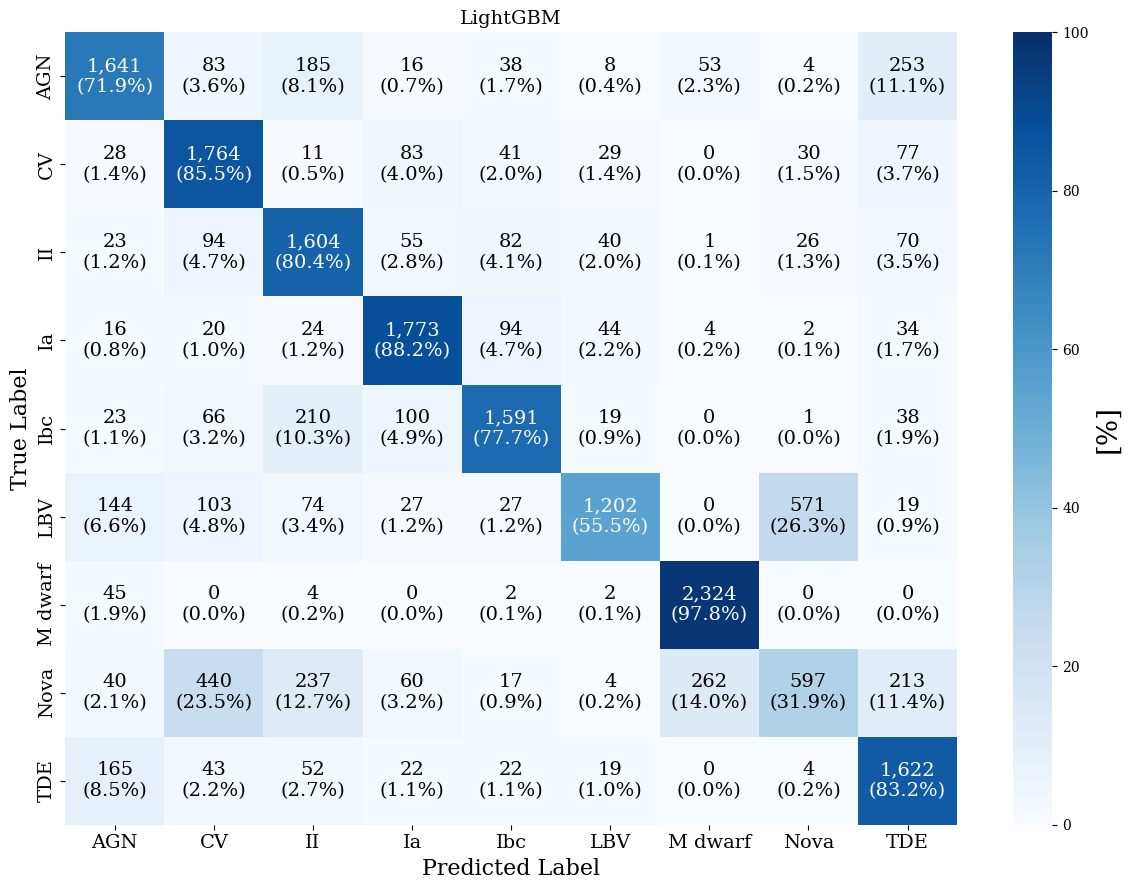

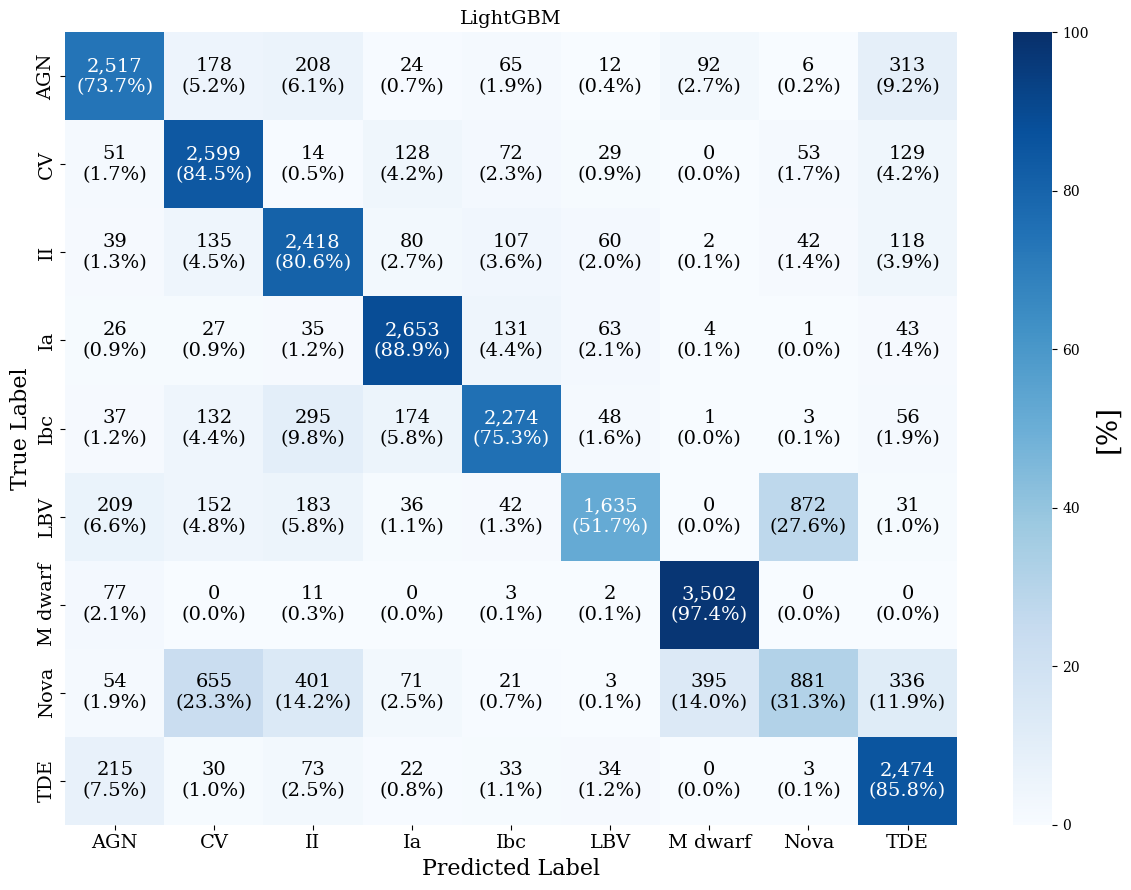

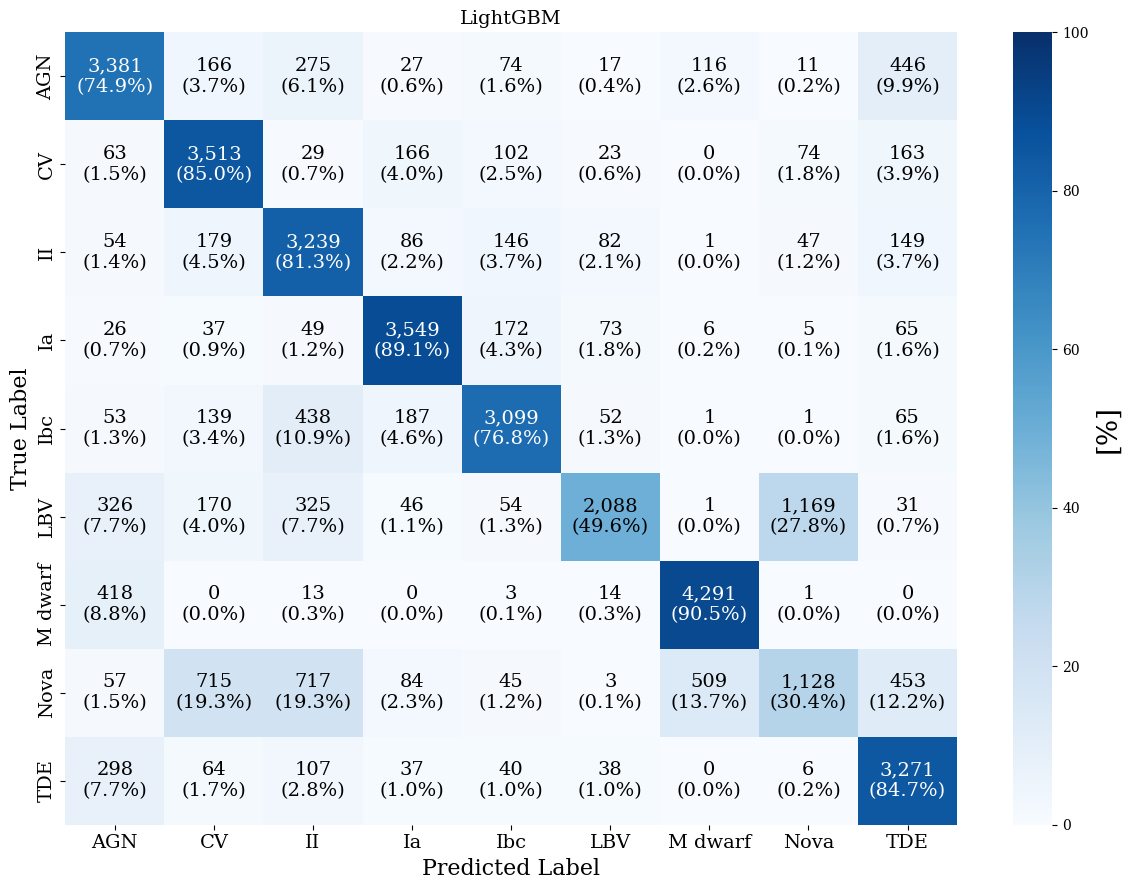

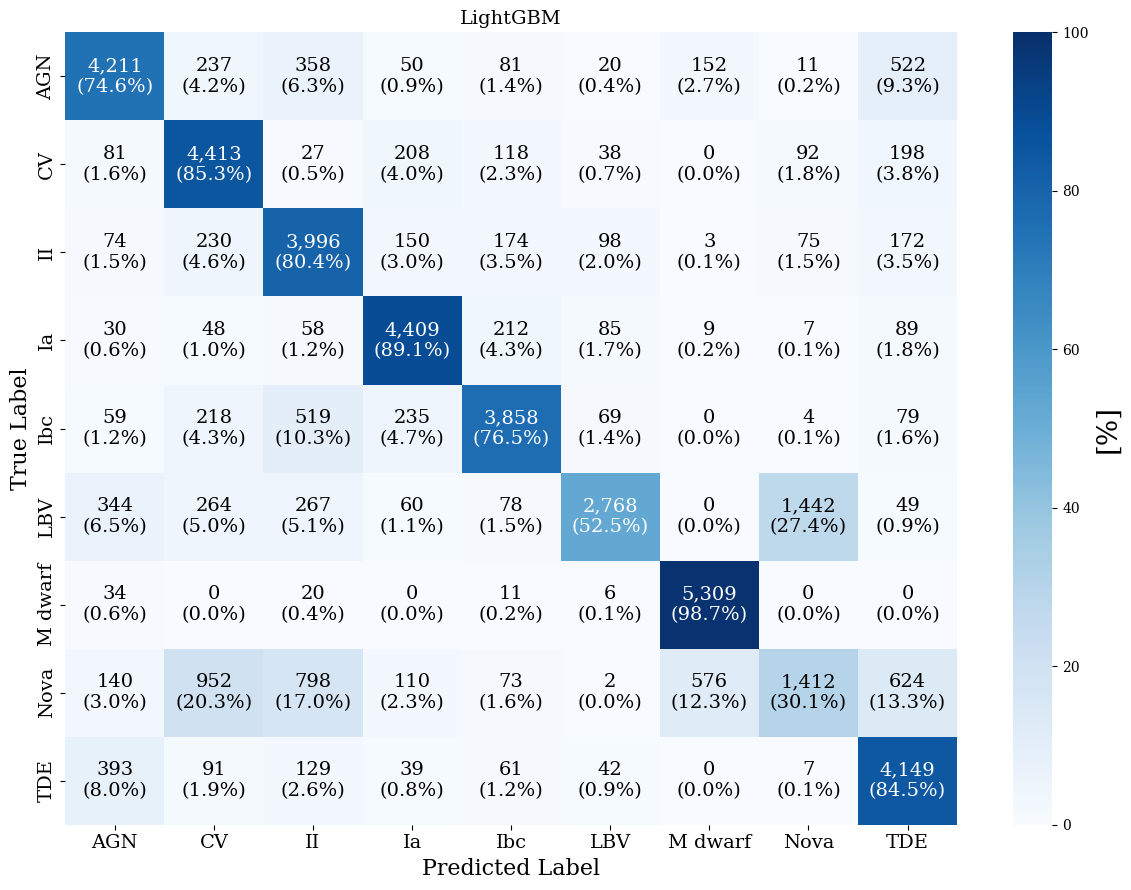

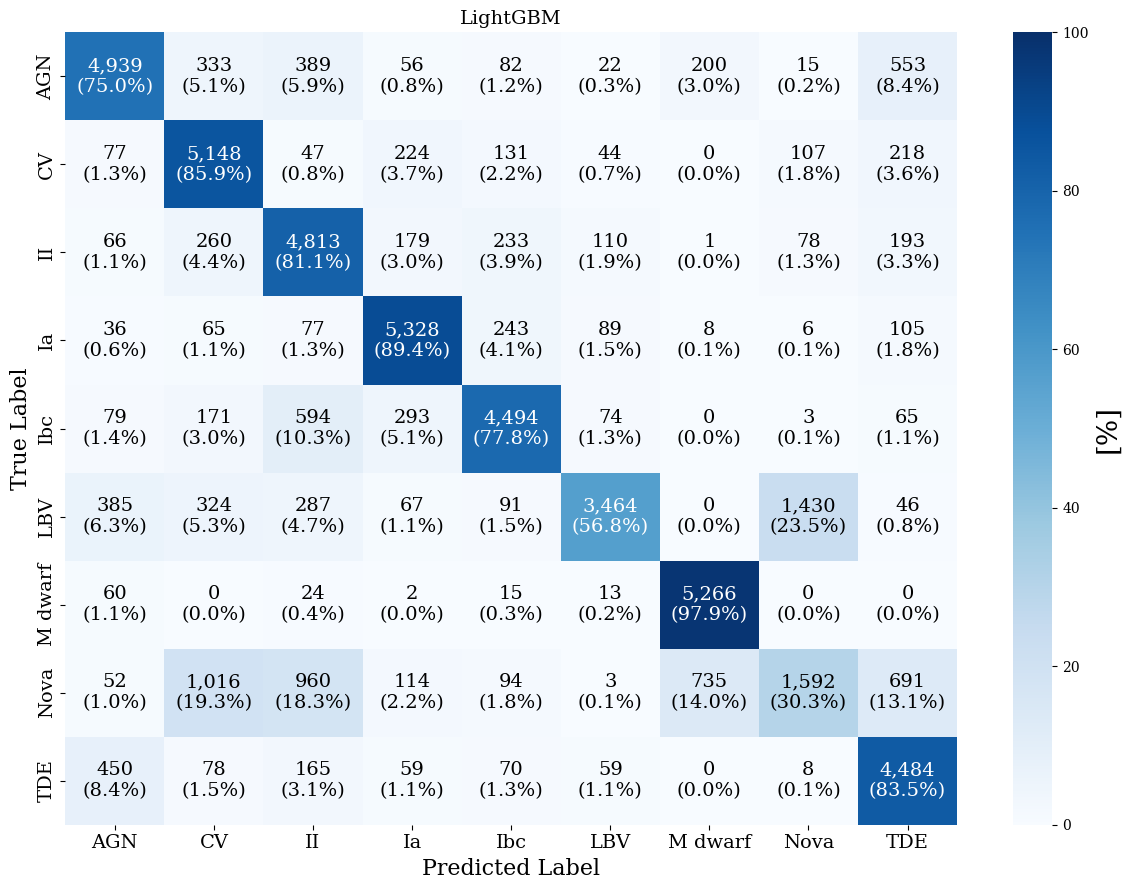

In [34]:
sample_numbers_per_class_to_test = [
    5000, 10000, 15000, 20000, 25000, 30000,
]

for sample_number in sample_numbers_per_class_to_test:

	# X_train_balanced_choiced, X_test_balanced_choiced, y_train_balanced_choiced, y_test_balanced_choiced = sample_by_class(X_balanced, y_balanced, data_balanced, sample_number)
	X_train_balanced_choiced, X_test_balanced_choiced, y_train_balanced_choiced, y_test_balanced_choiced = sample_by_class_uidwise(X_balanced, y_balanced, data_balanced, sample_number)

	y_train_sub_balanced_enc = label_encoder.transform(y_train_balanced_choiced)
	y_test_sub_balanced_enc = label_encoder.transform(y_test_balanced_choiced)

	lgbm_exp_sub_balanced = LightGBMExperiment(
		X_train_balanced_choiced, X_test_balanced_choiced,
		y_train_sub_balanced_enc, y_test_sub_balanced_enc,
		data_balanced, label_encoder, params,
		eval_metrics_list, path_save, do_cv=False
	)

	model_sub_balanced, metrics_sub_balanced = lgbm_exp_sub_balanced.run()
	lgbm_exp_sub_balanced.plot_confusion_matrix()
	cm_sub_balanced, labels_sub_balanced = lgbm_exp_sub_balanced.get_confusion_matrix()
	cm_dict[f'sub_balanced_n{sample_number}'] = cm_sub_balanced

	metrics_sub_balanced['test_name'] = f'sub_balanced_n{sample_number}'
	metrics_list.append(metrics_sub_balanced)
	# break  # 여러 sample_number 실험을 원한다면 break 제거

# Result

In [40]:
metrics_df = pd.concat(metrics_list, ignore_index=True)

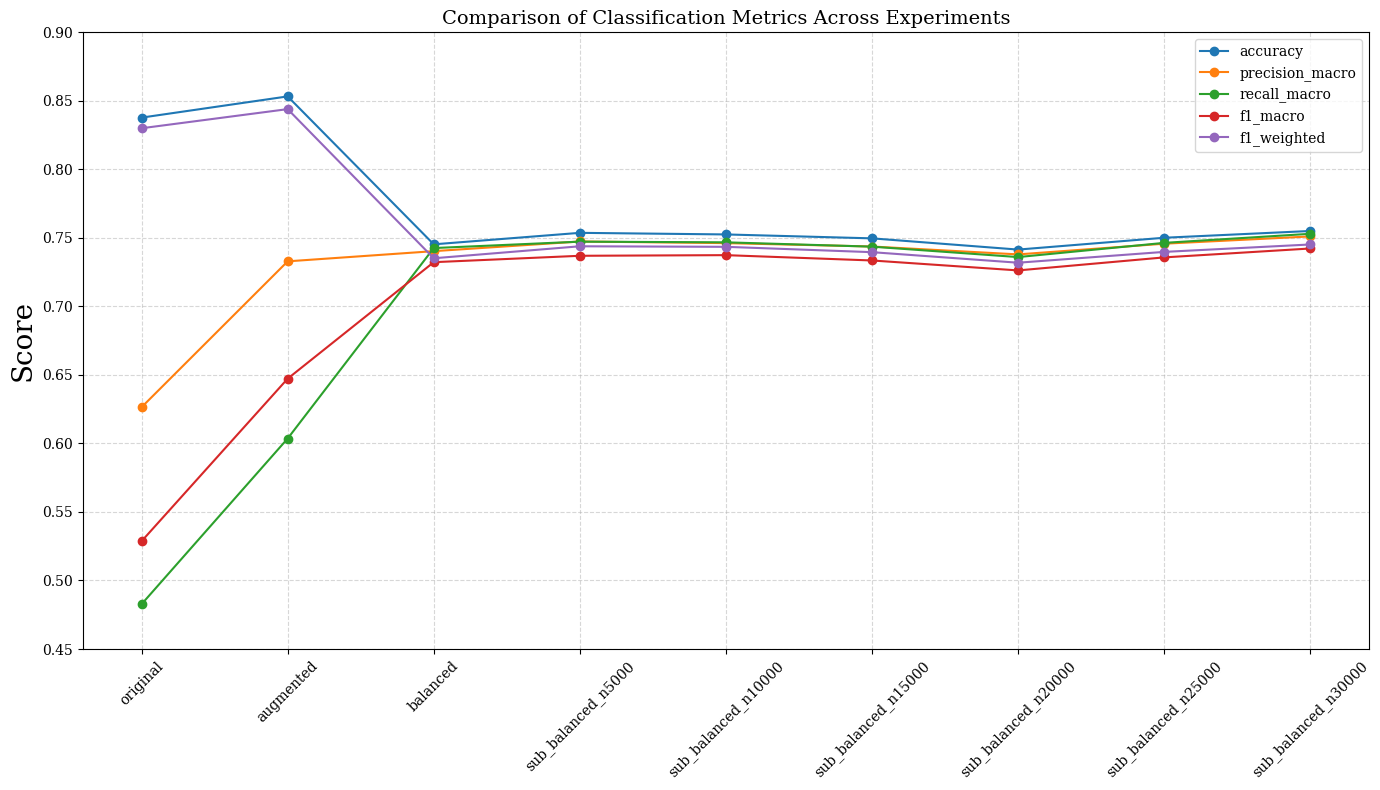

In [41]:
# Plot metrics comparison
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metrics_to_plot):
    plt.plot(metrics_df["test_name"], metrics_df[metric], marker='o', label=metric, color=colors[i])

plt.xticks(rotation=45)
plt.ylabel("Score")
plt.ylim(0.45, 0.9)
plt.title("Comparison of Classification Metrics Across Experiments")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

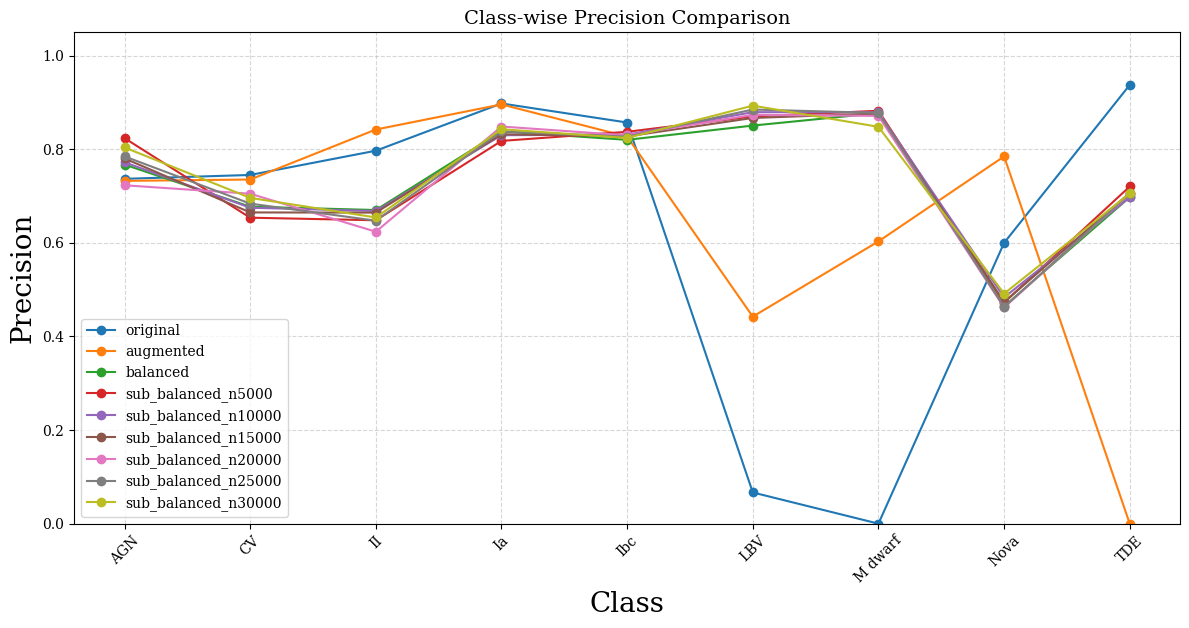

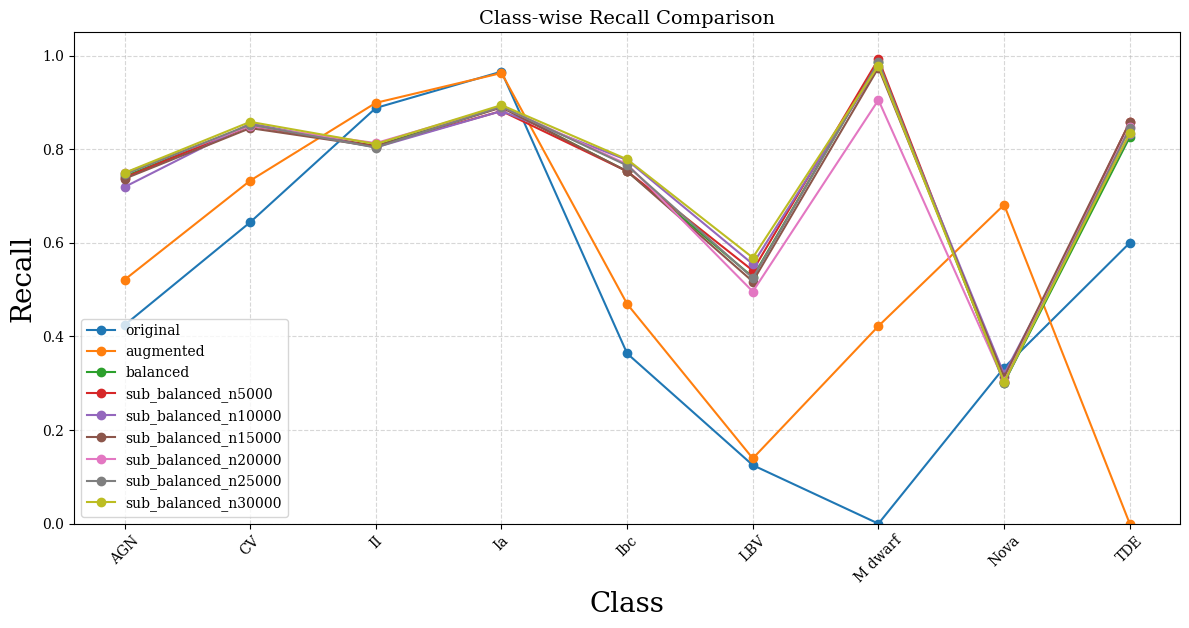

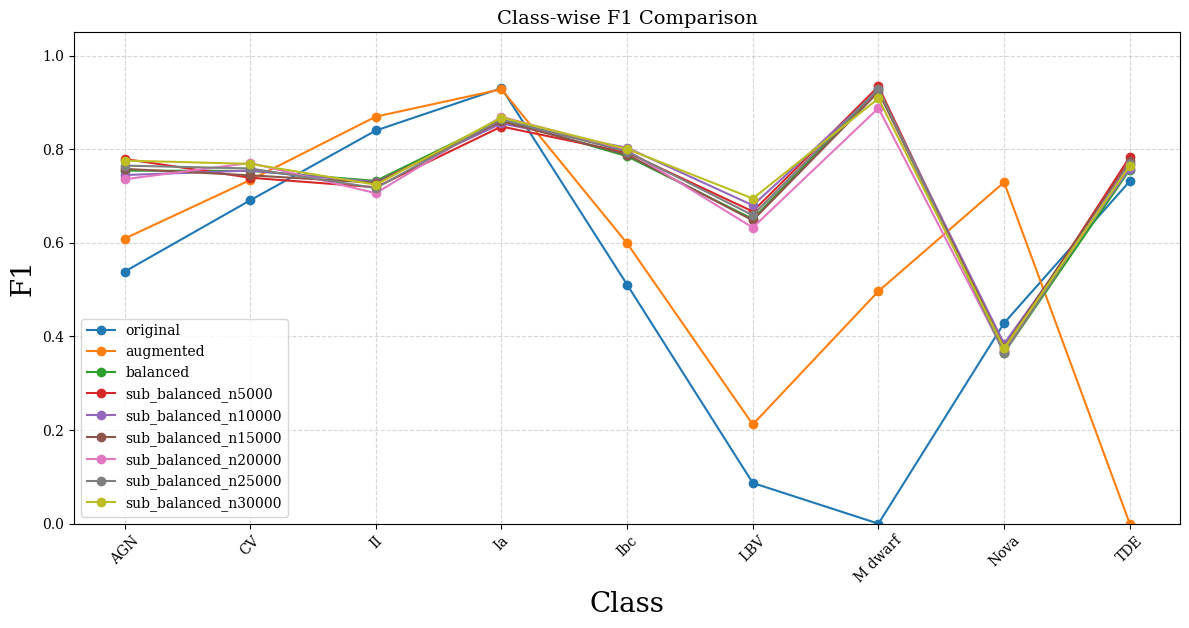

In [43]:
from sklearn.metrics import precision_recall_fscore_support

# 클래스 라벨 (예시)
class_names = ['AGN', 'CV', 'II', 'Ia', 'Ibc', 'LBV', 'M dwarf', 'Nova', 'TDE']

# 클래스별 지표 저장용
records = []

for name, cm in cm_dict.items():
    y_true = []
    y_pred = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            y_true.extend([i] * cm[i, j])
            y_pred.extend([j] * cm[i, j])
    # 각 클래스별 precision, recall, f1 계산
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    for i, cls in enumerate(class_names):
        records.append({
            'experiment': name,
            'class': cls,
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i]
        })

# DataFrame으로 변환
df_metrics = pd.DataFrame(records)

# === 시각화 ===
metrics = ['precision', 'recall', 'f1']

for metric in metrics:
    plt.figure(figsize=(12, 6))
    for name in cm_dict.keys():
        subset = df_metrics[df_metrics['experiment'] == name]
        plt.plot(subset['class'], subset[metric], marker='o', label=name)
    
    plt.title(f'Class-wise {metric.title()} Comparison')
    plt.ylabel(metric.title())
    plt.xlabel('Class')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

In [37]:
# 모든 결과를 하나의 csv로 저장
metrics_all = pd.concat(metrics_list, ignore_index=True)
metrics_all.to_csv(os.path.join(path_save, "metrics_summary.csv"), index=False)
print("Experiment complete. Results saved in:", path_save)

Experiment complete. Results saved in: /Users/paek/Research/7DT/SED-Classifier/notebook/../model/different_sampling
